# K-Means Clustering

K-means is a suitable clustering method due to its simplicity, efficiency, and interpretability. 
- It is selected for its conceptual simplicity, speed and popularity (Turner et al., 2018), highlighting that it is both easy to implement and widely trusted. 
- In addition, it is a simple, fast algorithm that is computationally efficient (Turner et al., 2018), making it well-suited for large datasets such as galaxy surveys. 
- Furthermore, k-means produces interpretable results. In the research, the final centroids are cluster archetypes (Turner et al., 2018). This implies each cluster can be understood as a representative type of galaxy, which is particularly valuable for astronomical analysis.

#### Research article referenced for K Means
1) Turner, S., Kelvin, L. S., Baldry, I. K., Lisboa, P. J., Longmore, S. N., Collins, C. A., Holwerda, B. W., Hopkins, A. M., & Liske, J. (2018). Reproducible k-means clustering in galaxy feature data from the GAMA survey. Monthly Notices of the Royal Astronomical Society, 482(1), 126–150. https://doi.org/10.1093/mnras/sty2690

Key applications and insights:
- Justification of KMeans clustering as an unsupervised clustering tool for analysis of large extragalstic datasets: Scalable, adaptable and providing crucial insight into the fundamental properties of astral objects 
- Stability Analysis (Original Code: https://github.com/sebturne/stacopy/blob/main/stacopy_example.ipynb): The stacopy framework guides K-means by identifying the most stable clustering for a given k and suggesting optimal k values. It complements standard methods like elbow plots and silhouette scores, ensuring that clustering results are reproducible and robust.
- Integration into K-means workflow: After candidate k values are identified using more conventional metrics (i.e. elbow plot + silhouette score), stacopy validates their consistency, strengthening confidence in the identified cluster structure.



#### Import libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Import Dataset

In [2]:
df = pd.read_csv("../astral_data.csv")
df.head()
df_features = df.iloc[:, :-1]
df_features.head()

,u-g,g-r,r-i,i-z,redshift_log
0,0.282719,0.199441,0.311683,0.203881,-0.145579
1,0.082746,0.183756,1.123312,0.428709,-0.549480
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675
3,0.397933,0.144873,0.426494,0.523488,-0.196892
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149


#### Choice of K

- Elbow: Measures compactness (how tight clusters are)
- Sihouette score: Measures separation + cohesion (Compares how close points are to their own cluster vs other clusters)

Elbow alone is often ambiguous as there is no clear elbow, while sihouette alone can be misleading as it favours simpler structures. Hence, combining them gives a more robust decision.

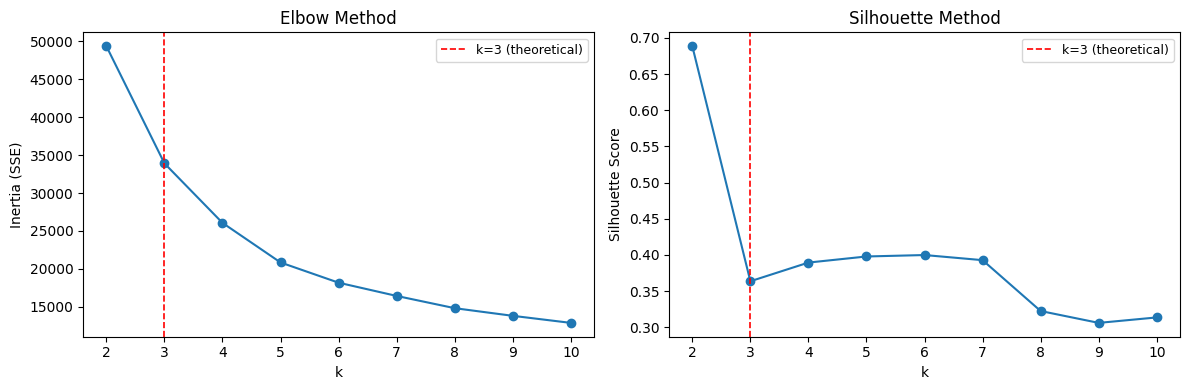

In [3]:
np.random.seed(42)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_features)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_features, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method")
axes[0].legend(fontsize=9)

# Silhouette plot
axes[1].plot(k_range, silhouettes, marker='o')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Interpretation of results:

There seems to be some tension between the theoretical expectation and what the actual data is suggesting for the clustering model.

Elbow:
- Trend: There is a sharp drop from k=2 to k=4, but a distinct "elbow" appears more prominently at k=4 or k=5, rather than the theoretical expectation k = 3.
- Implication: Choosing k=3 might leave the clusters too broad, as there is still a significant gain in compactness by moving to 4 clusters.

Silhouette:
- Trend: There is a massive peak at k=2, which suggests that the data most naturally splits into two very distinct groups.At the theoretical expectation k = 3, the silhouette score drops significantly to ~0.36. After the drop at k=3, the score recovers slightly and plateaus between k=4 and k=7 before dropping again. 
- Implication: This suggests a third cluster may create significant overlap or misclassified, making the clusters poorly defined.

#### Cluster Stability for Optimal K

STACO measures solution stability. We ran 100 random initialisations to check how consistently K-Means produce the same clustering.  
- A Cramér's V near 1.0 means every random start converges to the same solution. 
- A lower score means different starts produce meaningfully different clusterings.

Clustering...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.
Labels saved.
Measuring stabilities...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.

staco shape: (900, 3)  (columns: stability, compactness, k)


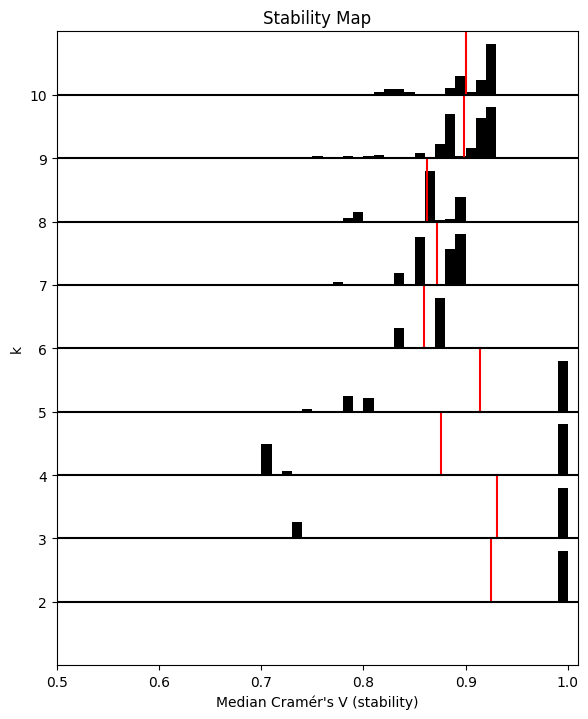

In [ ]:
# Additional imports required by stacopy
import scipy.stats
import sklearn.metrics
import joblib
import os
import glob

def V(matrix):
    """
    Calculates Cramer's V index of association from a confusion matrix.
    Cramer's V ranges from 0 (no association) to 1 (perfect agreement).
    Use sklearn.metrics.confusion_matrix to set up a confusion matrix.
    """
    chi = scipy.stats.chi2_contingency(matrix)[0]
    n = matrix.sum()
    return np.sqrt(chi / (n * (min(matrix.shape) - 1)))


def STACOK(data, k, seed):
    """
    Runs k-means once for input data at input k.
    Returns labels (array) and compactness (inertia).
    """
    kmrun = KMeans(
        n_clusters=k,
        max_iter=data.shape[0],
        n_init=1,
        tol=0,
        init='k-means++',
        random_state=seed # keeps all init runs deterministic yet different
    ).fit(data)
    return kmrun.predict(data), kmrun.inertia_


def STACOV(lbls, i):
    """
    Calculates median Cramer's V for the ith solution w.r.t. all other
    solutions at the same k. Higher = more stable/consistent.

    Args:
        lbls: (n_obs, init) array of cluster labels for all solutions at one k
        i:    index of the solution to evaluate
    Returns:
        Median Cramer's V across all pairwise comparisons
    """
    lbls_others = np.delete(lbls, i, axis=1)
    cvind = np.zeros((lbls_others.shape[1], 1))
    for q in range(lbls_others.shape[1]):
        cvind[q, 0] = V(sklearn.metrics.confusion_matrix(lbls[:, i], lbls_others[:, q]))
    return np.median(cvind)


def STACO(data, k=range(2, 11), init=100, save_lbls=False, master_seed=42):
    """
    Runs stacopy: calculates stabilities and compactnesses for `init` solutions
    at each value of k.

    Args:
        data:      (n_obs, n_features) array — clustering features only,
                   no IDs or flags. Data should already be scaled/normalised.
        k:         iterable of k values to evaluate (default: range(2, 11))
        init:      number of k-means initialisations per k (default: 100)
        save_lbls: if True, saves label arrays to 'lbls_k{k}.txt' files
        seed: keeps runs deterministic yet different

    Returns:
        (init*len(k), 3) array with columns:
            [0] stability  — median Cramer's V
            [1] compactness — k-means inertia (phi)
            [2] k           — value of k
    """
    obs, feats = data.shape
    nk = len(k)
    k = list(k)

    lbls = np.zeros((obs, init, nk))
    phi  = np.zeros((init, nk))

    # Generate unique seeds for every (k, init) combination upfront
    rng   = np.random.default_rng(master_seed)
    seeds = rng.integers(0, 1_000_000, size=(nk, init))

    print("Clustering...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        l, p = zip(*joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOK)(data, k[j], int(seeds[j, i])) for i in range(init)
        ))
        lbls[:, :, j] = np.transpose(np.array(l))
        phi[:, j]     = np.transpose(np.array(p))
    print("Done.")

    if save_lbls:
        for j in range(nk):
            np.savetxt(f'lbls_k{k[j]}.txt', lbls[:, :, j], delimiter=',')
        print("Labels saved.")

    cvmed = np.zeros((init, nk))

    print("Measuring stabilities...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        cvmed[:, j] = joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOV)(lbls[:, :, j], i) for i in range(init)
        )
    print("Done.")

    cvmed = cvmed.flatten('F').reshape(-1, 1)
    phi   = phi.flatten('F').reshape(-1, 1)
    k_arr = (np.ones((init, 1)) * k).flatten('F').reshape(-1, 1)

    return np.hstack((cvmed, phi, k_arr))

# Run Stacopy on data
k    = range(2, 11)  # candidate k values to evaluate
init = 100            # number of k-means runs per k (use 100 for final analysis)

data = np.array(df_features)  # ensure numpy array

lbls_dict = {}  # store labels in memory instead of disk

if __name__ == '__main__':
    staco = STACO(data, k=k, init=init, save_lbls=True, master_seed = 42)  # let it save temporarily

    # Read all saved label files into memory, then delete them
    for ki in k:
        fname = f'lbls_k{ki}.txt'
        if os.path.exists(fname):
            lbls_dict[ki] = np.genfromtxt(fname, delimiter=',')
            os.remove(fname)  # delete after reading

    # Also clean up staco results file
    if os.path.exists('staco_results.txt'):
        staco = np.genfromtxt('staco_results.txt', delimiter=',')
        os.remove('staco_results.txt')

    print(f"\nstaco shape: {staco.shape}  (columns: stability, compactness, k)")

# Plot stability map
fig, ax = plt.subplots(figsize=(6, 0.7 * len(k) + 1))

for i in k:
    cvs = staco[staco[:, 2] == i, 0].reshape(-1, 1)

    hist, bins = np.histogram(cvs, bins=np.arange(0.0, 1.01, 0.01))
    hist = (hist.astype(float) / float(max(hist))) * 0.8

    ax.plot([0.0, 1.01], [i, i], c='k', ls='-', lw=1.5, zorder=3)
    ax.bar(bins[1:] - 0.005, hist, width=0.01, bottom=i, color='k')
    ax.plot([np.mean(cvs), np.mean(cvs)], [i, i + 1], 'r-', lw=1.5)

ax.set(
    yticks=list(k),
    xlim=(0.5, 1.01),
    ylim=(min(k) - 1, max(k) + 1),
    xlabel='Median Cramér\'s V (stability)',
    ylabel='k'
)
ax.set_title('Stability Map')
plt.tight_layout()
plt.show()

Extremely high stability at K = 2 and K = 3
- Implication: The clustering algorithm almost always reaches the same conclusion. While we previously saw that k=3 had a poor silhouette score, this map shows that the k=3 partition is at least robust. This implies the algorithm is consistent but it's likely forcing a split that creates overlap.

Slightly lower stability at K = 4 to K = 6
- Observation: The stability remains high, but there are small outliers in the distribution. 
- Implication: This indicates the clustering is becoming slightly more sensitive to the specific data points included.

Instability at K >= 7
- Observation: The distribution of scores spreads out significantly toward the left.
- Implication:  The clusters are becoming less stable and noisy. The algorithm is likely finding patterns that are artifacts of specific data subsets rather than a true underlying structure.



Hence, we will further investigate the following choices of k:

1) K = 2: Possible Primary Candidate
- The silhouette Score was at its peak at 0.7, indicating that the data naturally separates into two very distinct, well-defined groups with minimal overlap.
- The high Median Cramér’s V implies this two-cluster structure is extremely robust and doesn't change regardless of we sample the data.

2) K = 3: Physical Prior
- Physical prior of Stars, QSOs and Galaxies allows direct comparison between true clusters and predicted clusters during evaluation.
- While the sihouette score suggests the natural overlap between these states, the stability graph confirms that the k=3 partition is a persistent and reproducible feature of the dataset

3) K = 4, 5: Possible Secondary Candidates
- The elbow drop starts to level off at around K = 4 and K = 5.
- After the significant drop at k=3, the silhouette score recovers at K = 4 and K = 5, suggesting that adding a 4th or 5th cluster may help re-segregate the data into more meaningful groups.
- K = 4 and K = 5 hence offers a balance between robustness and structural detail.

### K-Means Evaluation (K = 2, K = 3, K = 4, K = 5)

In [6]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, silhouette_samples,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Setup 
le     = LabelEncoder()
y_true = le.fit_transform(df["class"])

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_features)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3, 4, 5]

# Fit, evaluate, and store results for each k
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(df_features)

    sil = silhouette_score(df_features, labels)
    db  = davies_bouldin_score(df_features, labels)
    ch  = calinski_harabasz_score(df_features, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(df_features, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# Summary metrics table
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# Crosstab and per-cluster purity for each k
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.6887          0.5287      7292.12     49368.60   0.5935   0.6355
3        0.3636          0.8935      7525.93     33909.04   0.2062   0.3970
4        0.3895          0.7788      7505.40     26057.79   0.3038   0.5260
5        0.3978          0.7859      7648.85     20835.41   0.2310   0.4509

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8412  685     1
1            11    0   624

  Cluster 0 → GALAXY    (92.5% pure, n=9098)
  Cluster 1 → STAR      (98.3% pure, n=635)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0             4    0   624
1          4859   51     1
2          3560  634     0

  Cluster 0 → STAR      (99.4% pure, n=628)
  Cluster 1 → GALAXY    (98.9% pure, n=4911)
  Cluster 2 → GALAXY    (84.9% pure, n=4194)

k = 4  |  C

Interpretation and Conclusion

K = 2 (Primary candidate)
- At K = 2, the clustering achieves the best internal validation performance, with the highest silhouette score and strong Davies–Bouldin and Calinski–Harabasz values. This confirms that the dataset naturally separates into two highly compact and well-separated groups.
- However, when compared to the ground truth labels, this solution is overly simplistic. The model is effectively capturing a coarse division in the data, most likely driven by redshift rather than distinguishing the three astrophysical classes. As a result, different object types (i.e. galaxies and QSOs) are grouped together.
- This solution is statistically optimal but physically incomplete. It captures the dominant structure in the data but fails to resolve meaningful class distinctions.

K = 3 (Physical prior)
- At K = 3, the clustering aligns with the physical expectation of three object classes: STAR, GALAXY, and QSO. This allows for direct comparison with ground truth labels using ARI and NMI.
- The results show moderate agreement with true labels, indicating that the clustering is capturing some real structure. However, the drop in silhouette score suggests that the clusters are less well-separated geometrically, reflecting overlap between classes in feature space. This is expected as astrophysical objects can share similar properties.
- This is the most interpretable and physically meaningful solution, even if it is not geometrically optimal. It represents a balance between statistical structure and domain knowledge.

K = 4 (Secondary candidate)
- At K = 4, the results become more nuanced. While internal metrics do not outperform K = 2,introducing a fourth cluster allows for better separation of specific classes particularly QSOs. This suggests that the extra cluster is being used to resolve finer structure within the data that cannot be captured at K = 3.
- The recovery in silhouette score and continued high stability support the idea that K = 4 reflects secondary structure in the dataset. However, this comes at a cost, as clusters become less aligned with the original three-class interpretation and the interpretation becomes less straightforward.
- This solution captures finer-grained structure beyond the primary classes, making it useful for deeper analysis, but less suitable if the goal is to recover the original three categories.

K = 5 (Secondary candidate)
- At K = 5, the clustering begins to over-segment the data relative to the known class structure. The solution splits the data into 3 galaxy clusters, 1 star cluster, and 1 QSO cluster.
- While this reflects finer intra-class structure, it does not improve alignment with the ground truth, with lower NMI and ARI compared to K = 4.
- Although stability remains reasonably high, the reduced external validity and increased fragmentation make K = 5 less suitable than K = 4 for meaningful interpretation.


#### PCA Visualisation (K = 2, K = 3, K = 4)

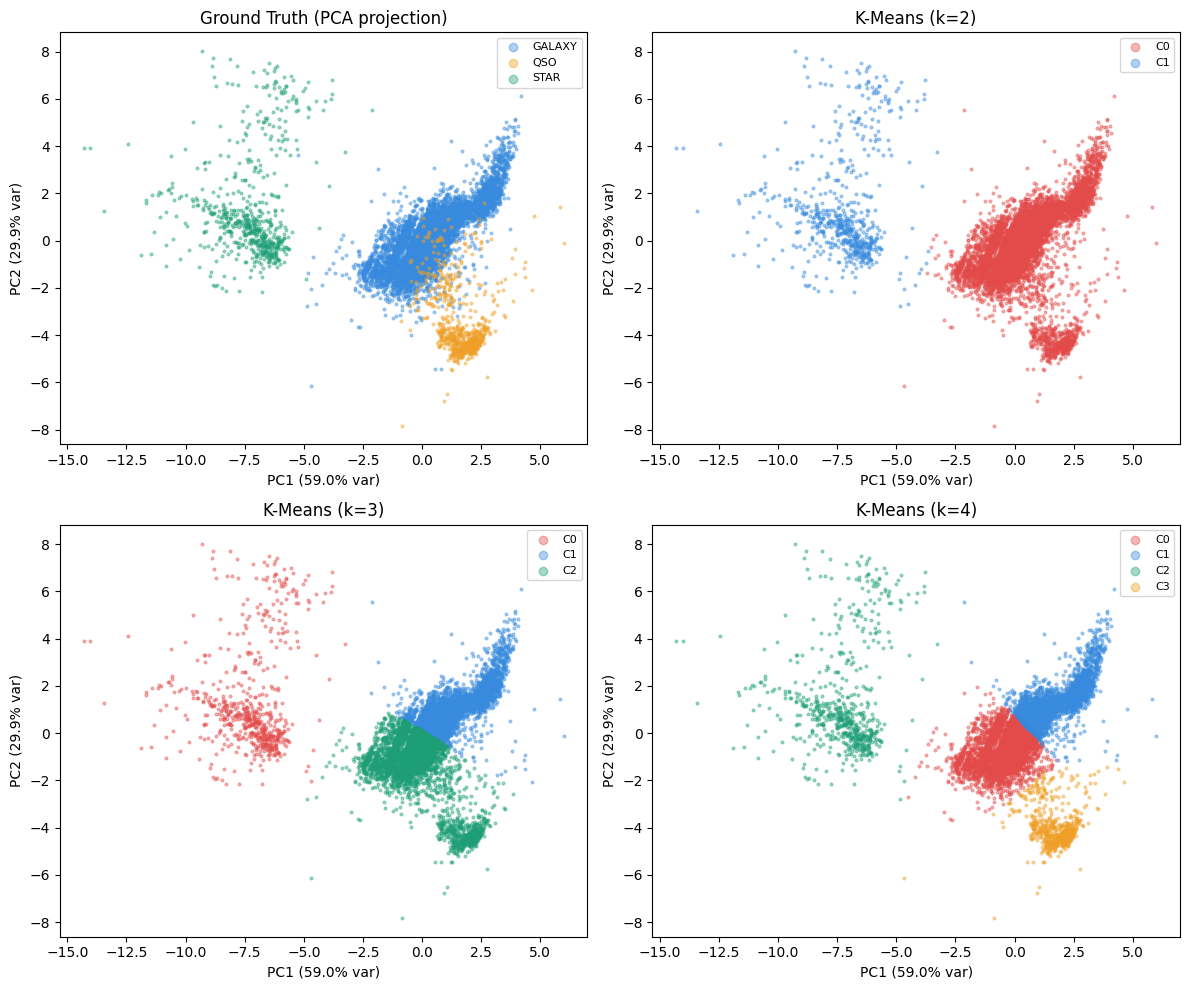

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 0: Ground truth
ax = axes[0]
for cls_name, col in class_colors.items():
    mask = df["class"] == cls_name
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=4, alpha=0.4, color=col, label=cls_name)

ax.set_title("Ground Truth (PCA projection)")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.legend(markerscale=3, fontsize=8)

# Remaining 3 plots
k_analysis = [2, 3, 4]
for i, k in enumerate(k_analysis, start=1):
    r      = results[k]
    labels = r["labels"]
    cols   = cluster_colors[:k]

    ax = axes[i]
    for j, cl in enumerate(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=cols[j], label=f"C{cl}")

    ax.set_title(f"K-Means (k={k})")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

Interpretation:

- Ground truth: The PCA projection reveals that stars form a compact and well-separated cluster, while galaxies and QSOs occupy an elongated, overlapping region. 

- At k=2, KMeans exploits this dominant separation, cleanly isolating stars but merging galaxies and QSOs into a single cluster.
- At k=3, although the number of clusters matches the known classes, KMeans partitions the elongated galaxy structure rather than separating QSOs, due to its assumption of spherical clusters. This results in clusters that do not align well with the true labels.
- At k=4, the additional cluster allows KMeans to better capture the lower PC2 region, successfully isolating QSOs into a distinct group. This suggests that the QSO class is distinguishable, but only when the model has sufficient flexibility to account for the non-spherical structure of the data.

#### Limitations and Conclusion

While KMeans provides useful insights into the structure of the data, the PCA visualisation highlights several important limitations of the method.

First, KMeans assumes that clusters are spherical and separable by Euclidean distance. However, the PCA plots show that the galaxy population forms an elongated, diagonal structure, while QSOs occupy a partially overlapping but directionally distinct region. This violates the underlying assumptions of KMeans, explaining why the algorithm struggles to recover the true class structure at k=3, despite this being the physically meaningful number of clusters.

Second, the results demonstrate that validation metrics can be misleading. For example, k=2 achieves the highest silhouette score by capturing the dominant separation between stars and non-stars, but fails to distinguish between galaxies and QSOs. Conversely, k=4 produces more meaningful class separation (particularly isolating QSOs), even though its geometric metrics are less optimal. This highlights the importance of incorporating domain knowledge and external validation metrics (when available and appropriate) when evaluating clustering performance.

#### Transition to Alternative Models

To better capture the structure of the classes, alternative clustering methods that do not rely on spherical assumptions should be considered.

This provides the motivation for our group to investigate the following models:

1) Gaussian Mixture Models (GMM):
GMM allows clusters to take on elliptical shapes through covariance estimation, making it more suitable for modelling the elongated galaxy distribution. It may also better separate overlapping classes such as galaxies and QSOs.

2) Density-Based Methods (DBSCAN / HDBSCAN):
These methods can identify clusters of arbitrary shape and are robust to noise. In particular, they may naturally separate the dense QSO region from the broader galaxy distribution without requiring a predefined number of clusters.